In [10]:
from fastai.vision.all import *
# from sklearn.metrics import roc_curve, auc
# from fastai.metrics import * 

# from pathlib import Path
from sklearn.model_selection import  train_test_split, GroupKFold, StratifiedGroupKFold, LeaveOneGroupOut, LeavePGroupsOut
from sklearn.utils import resample
import sklearn.metrics as skm
from pathlib import Path
import numpy as np
from numpy import random
import shutil
import glob
import os
path = Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6')

In [11]:
# Create some regular expression queries:
use = 'tiles'
(path/use).ls()
fname = (path/use).ls()[0]
print(fname.name)
re_class= r"class_(.+)_x\d+_y\d+.jpg"
out=re.findall(re_class,fname.name)
print(out)
re_slide =r'(.+)_class_\S+_x\d+_y\d+.jpg$'
out=re.findall(re_slide,fname.name)
print(out)
re_slide_class=r'(.+)_class_(.+)_x\d+_y\d+.jpg$'
slides=[]
slides_c=[]
all_c=[]
all_f=[]
for f in (path/use).ls():
    all_f.append(f.name)
    slide, c = re.findall(re_slide_class,f.name)[0]
    slides_c.append("%s_%s" % (slide,c))
    slides.append(slide)
    all_c.append(c)
print(np.unique(slides_c), len(np.unique(slides_c)))
posf = np.array([(f,c,s) for f,c,s in zip(all_f,all_c,slides) if c =='pos'])
negf = np.array([(f,c,s) for f,c,s in zip(all_f,all_c,slides) if c =='neg'])


1007482_class_pos_x19250_y13750.jpg
['pos']
['1007482']
['1007466_neg' '1007467_neg' '1007468_neg' '1007469_neg' '1007470_neg'
 '1007471_neg' '1007473_neg' '1007474_neg' '1007476_pos' '1007477_pos'
 '1007478_pos' '1007482_pos' '1007484_pos' '1007485_pos' '1007486_pos'
 '1007720_neg' '1007726_neg' '1007731_pos' '1007733_pos' '1007820_neg'
 '1007821_neg' '1007822_neg' '1007824_neg' '1007825_neg' '1007826_pos'
 '1007827_pos' '1007828_pos' '1007829_pos' '1007830_pos' '1007831_pos'
 '1007832_pos' '1007845_neg' '1007846_neg' '1007847_neg' '1007848_neg'] 35


In [5]:
#Check that all .svs files actually result in tiles being extracted:
path_raw_pos = path.parent.parent.joinpath('raw').joinpath('bile_ducts_pos')
path_raw_neg = path.parent.parent.joinpath('raw').joinpath('bile_ducts_neg')
all_svs = path_raw_pos.ls() + path_raw_neg.ls()
# print(all_svs)
re_raw_class=r'(+.).svs$'
missing = 0
for raw in all_svs:
    r_id = raw.parts[-1].split('.')[0]
    if r_id not in slides:
        if 'pos' in str(raw):
            c='pos'
        else:
            c='neg'
        print('%s %s not found in processed tiles!' % (r_id,c))
        missing +=1
if missing == 0:
    print('All %d .svs files have processed tiles.' % (len(all_svs)))
        

1007726 neg not found in processed tiles!


# Debug K-Fold!

In [40]:
#Debug k-fold``
u_slides_c=np.unique(slides_c)
temp = [item.split('_') for item in u_slides_c]
slide_df=pd.DataFrame(temp,columns=['slide','group'])
slide_df['class']=slide_df.loc[:,'group']=='pos'
slide_df.head()
lpgo = LeavePGroupsOut(n_groups=1)
# lpgo.get_n_splits(groups=slides)
# for train_index, test_index in lpgo.split(all_f, all_c, slides):
    # print(np.unique(np.array(slides)[test_index]))
    
gkf=GroupKFold(n_splits=10)
gkf.get_n_splits(slide_df.loc[:,'slide'],
                            slide_df.loc[:,'group'],
                            groups=slide_df.loc[:,'slide'])
for train_index, test_index in gkf.split(slide_df.loc[:,'slide'],
                            slide_df.loc[:,'group'],
                            groups=slide_df.loc[:,'slide']):
    npos = sum(slide_df.loc[train_index,'class'])
    pos_idx = slide_df.loc[train_index,'class']
    
    nneg = len(train_index) - npos
    if npos > nneg:
        resample(keep,
                          n_samples=ntarget,
                          random_state=42,
                          replace = False,)
        
    

16 15
15 16
14 17
14 17
14 17
14 18
14 18
13 19
15 17
15 17


In [48]:
def equal_class_by_slide(pos_set_groups,
                                             neg_set_groups,
                                             pos_set_fn,
                                             neg_set_fn,
                                             seed=42,
                                             ntarget=175,
                                             balance_classes=True,
                                             verbose=True):
    all_orig=[pos_set_fn,neg_set_fn]
    nneg=[]
    npos=[]
    all_new = [np.empty((1,3)),np.empty((1,3))]
    #For each slide / group in pos/neg set_groups, limit tiles used to ntarget
    for i,tset in enumerate( [pos_set_groups, neg_set_groups]):
        set_idx=[]
        if i==0:
            if verbose: print('\nPositive slides:')
            n=npos
        else:
            if verbose: print('\nNegative slides:')
            n=nneg

        for ii,slide_id in enumerate(tset):
            idx = all_orig[i][:,2]==slide_id
            keep = all_orig[i][idx,:]
            if ntarget >0: #If < 0, do not resample
                if keep.shape[0] > ntarget:
                    keep= resample(keep,
                          n_samples=ntarget,
                          random_state=42,
                          replace = False,)
            if ii==0:
                all_new[i]=keep
            else:
                all_new[i]=np.concatenate((all_new[i],keep),axis=0)
            ntiles=keep.shape[0]
            n.append(ntiles)
        if verbose:
            print('\t n = %d svs' % len(tset))
            print('\t median n tiles / svs = %4.1f' % np.median(n))
    if ntarget >0:
        print('Dataset has %d pos and %d neg tiles after per-slide equalization' % (np.sum(npos),np.sum(nneg)))
    else:
        print('Dataset has %d pos and %d neg tiles (no per-slide equalization if ntarget <=0)' % (np.sum(npos),np.sum(nneg)))
    
    #Overall randomly resample the classes to be perfect match:
    if balance_classes == True:
        min_rows = min(np.sum(npos), np.sum(nneg))
        if verbose: print('Smaller of the two: %d' % min_rows)
        res_pos =resample(all_new[0],
                          n_samples=min_rows,
                          random_state=seed,
                          replace = False,)
        res_neg =resample(all_new[1],
                          n_samples=min_rows,
                          random_state=seed,
                          replace = False,)
        all_output=np.concatenate((res_pos,res_neg),axis=0)
        print('Dataset has %d pos and %d neg tiles after total equalization' % (res_pos.shape[0],res_neg.shape[0]))
        # print('Total slides after balance = %d' % all_output.shape[0])
    else:
        all_output=np.concatenate((all_new[0],all_new[1]),axis=0)
        print('Dataset has %d pos and %d neg tiles (no equalization)' % (all_new[0].shape[0],all_new[1].shape[0]))
        # if verbose: print('Total slides = %d' % all_output.shape[0])
  

    
    return all_output

In [149]:
vp=[]
vn=[]
for seed in range(0,10):
    ntarget = 500
    train_pos, valid_pos = train_test_split(np.unique(posf[:,2]),
                                       test_size=0.2,
                                       random_state=seed)
    train_neg, valid_neg = train_test_split(np.unique(negf[:,2]),
                                       test_size=0.2,
                                       random_state=seed)
    
    print('\nTRAINING SET:', seed)
    all_train = equal_class_by_slide(train_pos, train_neg, posf, negf,
                                     seed=seed, ntarget=ntarget, verbose=False)

    print('Total len:', len(all_train), 'Unique len:', len(np.unique(all_train[:,0])))

    print('\nVALIDATION SET:', seed)
    all_valid = equal_class_by_slide(valid_pos, valid_neg, posf, negf,
                                 seed=seed,ntarget=0, balance_classes=False,
                                 verbose=False)
    print('Total len:', len(all_valid), 'Unique len:', len(np.unique(all_valid[:,0])))
    vp.append(valid_pos)
    vn.append(valid_neg)
    df0=pd.DataFrame(all_train,columns=['fn','class','slide'])
    df0['is_valid']=False
    df1=pd.DataFrame(all_valid,columns=['fn','class','slide'])
    df1['is_valid']=True
    df=pd.concat((df0,df1),axis=0)
    full_path_fn=[path.joinpath(use).joinpath(fn) for fn in df['fn']]
    df['full_path']=full_path_fn
    df.to_csv(path.joinpath('%s_model' % use).joinpath('resnet18_10kfold/csv').joinpath('train_valid_fold_%d.csv' % seed))
vn=np.array(vn).flatten()
vp=np.array(vp).flatten()
print(len(vp), len(np.unique(vp)), len(vn), len(np.unique(vn)))


TRAINING SET: 0
Dataset has 4436 pos and 3820 neg tiles after per-slide equalization
Dataset has 3820 pos and 3820 neg tiles after total equalization
Total len: 7640 Unique len: 7640

VALIDATION SET: 0
Dataset has 1802 pos and 984 neg tiles (no per-slide equalization if ntarget <=0)
Dataset has 1802 pos and 984 neg tiles (no equalization)
Total len: 2786 Unique len: 2786

TRAINING SET: 1
Dataset has 4036 pos and 3922 neg tiles after per-slide equalization
Dataset has 3922 pos and 3922 neg tiles after total equalization
Total len: 7844 Unique len: 7844

VALIDATION SET: 1
Dataset has 4344 pos and 823 neg tiles (no per-slide equalization if ntarget <=0)
Dataset has 4344 pos and 823 neg tiles (no equalization)
Total len: 5167 Unique len: 5167

TRAINING SET: 2
Dataset has 4503 pos and 3851 neg tiles after per-slide equalization
Dataset has 3851 pos and 3851 neg tiles after total equalization
Total len: 7702 Unique len: 7702

VALIDATION SET: 2
Dataset has 1751 pos and 894 neg tiles (no per-

In [132]:
df.head()

,fn,class,slide,is_valid,full_path
0,1007486_class_pos_x11000_y97000.jpg,pos,1007486,False,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v5/tiles/1007486_class_pos_x11000_y97000.jpg
1,1007485_class_pos_x25500_y10500.jpg,pos,1007485,False,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v5/tiles/1007485_class_pos_x25500_y10500.jpg
2,1007733_class_pos_x12000_y13500.jpg,pos,1007733,False,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v5/tiles/1007733_class_pos_x12000_y13500.jpg
3,1007830_class_pos_x19000_y116000.jpg,pos,1007830,False,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v5/tiles/1007830_class_pos_x19000_y116000.jpg
4,1007830_class_pos_x12000_y26000.jpg,pos,1007830,False,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v5/tiles/1007830_class_pos_x12000_y26000.jpg


In [108]:
# img_list=[fn for fn in df['fn']]
# def get_matched_list(path):
#     y=get_image_files(path)
#     return [fn for fn in y if fn.parts[-1] in img_list]

# img_list=[path.joinpath('tiles').joinpath(fn) for fn in df['fn']]
img_list=[fn for fn in df['fn']]
def get_matched_list(path):
    return L([path.joinpath(fn) for fn in img_list])

b=get_matched_list(path/"tiles")
len(b)
len(img_list)

9882

In [11]:
a = False
b = 'a' if a==True else 'b'
print(b)


b


In [6]:
#Fit 10 resnet18 models to full dataset
model_path = '%s_model' % use
export_path=path.joinpath(model_path).joinpath('resnet18_10kfold/fold_models')
csv_path=path.joinpath(model_path).joinpath('resnet18_10kfold/csv')
for seed in range(0,1):
    print('Fold :', seed)
    df=pd.read_csv(csv_path.joinpath('train_valid_fold_%d.csv' % seed))
    re_class=r'class_(.+)_x\d+_y\d+.jpg'
    tissue =DataBlock(blocks=(ImageBlock, CategoryBlock),
                      get_x=ColReader('full_path'),
                      splitter=ColSplitter('is_valid') ,# GrandparentSplitter(train_name='train',valid_name='valid'),
                      get_y=  ColReader('class'), #using_attr(RegexLabeller(re_class), 'name'),
                      item_tfms=Resize(460) if use == 'summary' else None,
                      batch_tfms=aug_transforms(size=224,
                                                max_rotate=45,
                                                min_scale=0.75,
                                                flip_vert=True,
                                               )
                                 ) 
    dls = tissue.dataloaders(df, bs = 128)
    learn = cnn_learner(dls, resnet18,
                    metrics=[error_rate, accuracy],
                    ).to_fp16()

    learn.fine_tune(5,freeze_epochs=1)
    learn.export(fname=export_path.joinpath('resnet18_1_5_%d.pkl' % seed))
    
    # learn = cnn_learner(dls, xresnet50,
    #                 metrics=[error_rate, accuracy],
    #                 ).to_fp16()
    # learn.fine_tune(5,freeze_epochs=2)
    # learn.export(fname=export_path.joinpath('xresnet50_2_5_%d.pkl' % seed))

Fold : 0


/ihome/rbao/bri8/envs/fastai/lib/python3.8/site-packages/torch/_tensor.py:1023: UserWarning: torch.solve is deprecated in favor of torch.linalg.solveand will be removed in a future PyTorch release.
torch.linalg.solve has its arguments reversed and does not return the LU factorization.
To get the LU factorization see torch.lu, which can be used with torch.lu_solve or torch.lu_unpack.
X = torch.solve(B, A).solution
should be replaced with
X = torch.linalg.solve(A, B) (Triggered internally at  /opt/conda/conda-bld/pytorch_1631630839582/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:760.)
  ret = func(*args, **kwargs)


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.868682,0.620764,0.279568,0.720432,08:48


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.617011,0.686777,0.323623,0.676377,03:37
1,0.481092,0.550696,0.256922,0.743078,03:38
2,0.372185,0.578756,0.245908,0.754092,03:37
3,0.320202,0.603741,0.236130,0.763870,03:38
4,0.290085,0.612127,0.247658,0.752342,03:39


In [4]:
model_path='%s_model' % use
print(model_path)
print(path)
infer_path=path.joinpath(model_path).joinpath('resnet18_10kfold/infer_csv')

tiles_model
/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6


In [5]:
# Examine test inference:
u_slides_c=np.unique(slides_c)
temp = [item.split('_') for item in u_slides_c]
fold_df=pd.DataFrame(temp,columns=['slide','class'])
s=time.time()
model_path='%s_model' % use
export_path=path.joinpath(model_path).joinpath('resnet18_10kfold/fold_models')
csv_path=path.joinpath(model_path).joinpath('resnet18_10kfold/csv')
infer_path=path.joinpath(model_path).joinpath('resnet18_10kfold/infer_csv')
for seed in range(0,10):
    print('Fold :', seed)
    df=pd.read_csv(csv_path.joinpath('train_valid_fold_%d.csv' % seed))
    model_fn=export_path.joinpath('resnet18_1_5_%d.pkl' % seed)
    learn = load_learner(model_fn)
    test_df=df.loc[df.loc[:,'is_valid']==1,:].reset_index()
    dl = learn.dls.test_dl(test_df.loc[:,'full_path'],
                          ) #device='cuda:2' #Does not work
    pred = learn.get_preds(dl=dl,with_decoded=True)
    
    test_slides=np.unique(test_df.loc[:,'slide'])
    p=np.array(pred[0]) # Probability ['neg','pos'] (Can check with dls.vocab )
    c=np.array(pred[2]) #Predictions decoded
    #Save all predictions:
    all_valid_df=df.loc[df.loc[:,'is_valid'],('fn','slide','class')]
    all_valid_df['p_pos']=p[1]
    all_valid_df['pred_cls']=c
    all_valid_df.to_csv(infer_path.joinpath('fold_%d_all_valid_pred.csv' % seed))
    
    fold_df['p1_fold_%d' % seed] = np.zeros((fold_df.shape[0],1))*np.nan
    fold_df['wta_fold_%d' % seed] = np.zeros((fold_df.shape[0],1))*np.nan
    for slide in test_slides:
        src_idx = np.array(test_df.loc[:,'slide']) == slide
        p1 = np.mean(p[src_idx,1])
        if np.sum(c[src_idx]==0) > np.sum(c[src_idx]==1):
            wta=0
        else:
            wta=1
        dest_idx = np.array(fold_df.loc[:,'slide'])== str(slide)
        # print(dest_idx,p1)
        fold_df.loc[dest_idx,'p1_fold_%d' % seed] = p1
        fold_df.loc[dest_idx,'wta_fold_%d' % seed] = wta
ss=time.time()
print('Wall time: %ds' % (ss-s))
fold_df.head()
fold_df.to_csv(infer_path.joinpath('fold_summary.csv'))

Fold : 0


FileNotFoundError: [Errno 2] No such file or directory: '/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles_model/resnet18_10kfold/fold_models/resnet18_1_5_0.pkl'

In [13]:
start=0
stop=1
u_slides_c=np.unique(slides_c)
temp = [item.split('_') for item in u_slides_c]
fold_df=pd.DataFrame(temp,columns=['slide','class'])
s=time.time()
model_path='%s_model' % use
export_path=path.joinpath(model_path).joinpath('resnet18_10kfold/fold_models')
csv_path=path.joinpath(model_path).joinpath('resnet18_10kfold/csv')
infer_path=path.joinpath(model_path).joinpath('resnet18_10kfold/infer_csv')
for p in [export_path, infer_path]:
    if p.exists()==False:
        os.makedirs(p)

for seed in range(start,stop):
    print('Perform inference on fold :', seed)
    df=pd.read_csv(csv_path.joinpath('train_valid_fold_%d.csv' % seed))
    model_fn=export_path.joinpath('resnet18_1_5_%d.pkl' % seed)
    learn = load_learner(model_fn)
    test_df=df.loc[df.loc[:,'is_valid']==1,:].reset_index(drop=True)
    dl = learn.dls.test_dl(test_df.loc[:,'full_path'],
                          bs=128) #device='cuda:2' #Does not work
    print('Beginning inference:')
    pred = learn.get_preds(dl=dl,with_decoded=True)
    
    test_slides=np.unique(test_df.loc[:,'slide'])
    p=np.array(pred[0]) # Probability ['neg','pos'] (Can check with dls.vocab )
    c=np.array(pred[2]) #Predictions decoded
    #Save all predictions:
    
    test_df['p_pos']=p[:,1]
    test_df['pred_cls']=c
    fn= infer_path.joinpath('fold_%d_all_valid_pred.csv' % seed)
    print('Saving all validation inferences to %s' %fn)
    test_df.to_csv(fn)
    
    fold_df['p1_fold_%d' % seed] = np.zeros((fold_df.shape[0],1))*np.nan
    fold_df['wta_fold_%d' % seed] = np.zeros((fold_df.shape[0],1))*np.nan
    for slide in test_slides:
        src_idx = np.array(test_df.loc[:,'slide']) == slide
        p1 = np.mean(p[src_idx,1])
        if np.sum(c[src_idx]==0) > np.sum(c[src_idx]==1):
            wta=0
        else:
            wta=1
        dest_idx = np.array(fold_df.loc[:,'slide'])== str(slide)
        # print(dest_idx,p1)
        fold_df.loc[dest_idx,'p1_fold_%d' % seed] = p1
        fold_df.loc[dest_idx,'wta_fold_%d' % seed] = wta
ss=time.time()
print('Wall time: %ds' % (ss-s))
# fold_df.head()

fn=infer_path.joinpath('fold_summary.csv')
print('Saving inference summary to %s' % fn)
fold_df.to_csv(fn)
print('Finished')

Perform inference on fold : 0
Beginning inference:


IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

In [19]:
test_df.head()

,Unnamed: 0,fn,class,slide,is_valid,full_path,p_pos,pred_cls
0,0,1007477_class_pos_x41750_y9750.jpg,pos,1007477,True,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles/1007477_class_pos_x41750_y9750.jpg,0.984933,1
1,1,1007477_class_pos_x36000_y9000.jpg,pos,1007477,True,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles/1007477_class_pos_x36000_y9000.jpg,0.550030,1
2,2,1007477_class_pos_x35500_y11000.jpg,pos,1007477,True,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles/1007477_class_pos_x35500_y11000.jpg,0.098845,0
3,3,1007477_class_pos_x42250_y9000.jpg,pos,1007477,True,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles/1007477_class_pos_x42250_y9000.jpg,0.940548,1
4,4,1007477_class_pos_x35500_y9750.jpg,pos,1007477,True,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles/1007477_class_pos_x35500_y9750.jpg,0.230625,0


In [ ]:
def test_set(dsets, test_items, rm_tfms=None, with_labels=False):
    "Create a test set from `test_items` using validation transforms of `dsets`"
    if isinstance(dsets, Datasets):
        tls = dsets.tls if with_labels else dsets.tls[:dsets.n_inp]
        test_tls = [tl._new(test_items, split_idx=1) for tl in tls]
        if rm_tfms is None: rm_tfms = [tl.infer_idx(get_first(test_items)) for tl in test_tls]
        else:               rm_tfms = tuplify(rm_tfms, match=test_tls)
        for i,j in enumerate(rm_tfms): test_tls[i].tfms.fs = test_tls[i].tfms.fs[j:]
        return Datasets(tls=test_tls)
    elif isinstance(dsets, TfmdLists):
        test_tl = dsets._new(test_items, split_idx=1)
        if rm_tfms is None: rm_tfms = dsets.infer_idx(get_first(test_items))
        test_tl.tfms.fs = test_tl.tfms.fs[rm_tfms:]
        return test_tl
    else: raise Exception(f"This method requires using the fastai library to assemble your data. Expected a `Datasets` or a `TfmdLists` but got {dsets.__class__.__name__}")

In [221]:
fold_df.to_csv(export_path.parent.joinpath('fold_summary.csv'))

[0.52992213 0.21072223 0.306874   0.19390796 0.70529312 0.10043073
 0.59939089 0.34244689 0.3798006  0.40377624 0.60211077 0.38657179
 0.75506413 0.60354442 0.66276437 0.25359228 0.15629013 0.53104091
 0.84262857 0.54222639 0.29825913 0.52303231        nan 0.60760242
 0.45737192 0.5906198  0.29903647 0.68806225 0.72970636 0.37020445
        nan 0.20438273 0.59467373 0.67846382 0.39325027]
[1. 0. 0. 0. 1. 0. 3. 0. 0. 0. 4. 0. 2. 2. 4. 0. 0. 4. 2. 3. 0. 2. 0. 2.
 0. 1. 0. 3. 4. 0. 0. 0. 3. 1. 0.]
0.6060606060606061
[[10  8]
 [ 5 10]]


<ipython-input-238-54578283b019>:9: RuntimeWarning: Mean of empty slice
  print(np.nanmean(p1,axis=1))
<ipython-input-238-54578283b019>:14: RuntimeWarning: All-NaN slice encountered
  m_p1=np.nanmax(p1,axis=1)


Text(0.5, 1.0, 'AUROC 0.741, Sensitivity: 0.67, Specificity: 0.56')

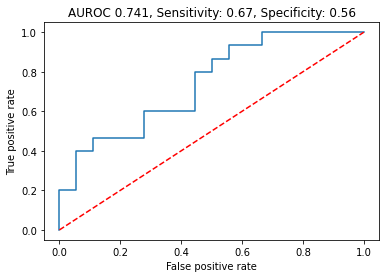

In [238]:
fold_df=pd.read_csv(export_path.parent.joinpath('fold_summary.csv'))
p1=[]
wta=[]
for fold in range(0,10):
    p1.append(np.array(fold_df.loc[:,'p1_fold_%d' % fold]))
    wta.append(np.array(fold_df.loc[:,'wta_fold_%d' % fold]))
p1=np.array(p1).transpose()
wta=np.array(wta).transpose()
print(np.nanmean(p1,axis=1))
print(np.nansum(wta,axis=1))
# pred_pos = np.nansum(wta,axis=1)>0 

true_pos = np.array(fold_df.loc[:,'class'])=='pos'
m_p1=np.nanmax(p1,axis=1)
pred_pos = m_p1 > 0.5
use = ~np.isnan(m_p1)
# sum(exc)
print(np.sum(pred_pos[use] == true_pos[use]) / np.sum(use) )

fpr,tpr,thresh =skm.roc_curve(true_pos[use],m_p1[use])
# pred_pos = m_p1 > 0.5
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--r')
c=skm.confusion_matrix(true_pos[use],pred_pos[use])

auc=skm.auc(fpr,tpr)

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
print(c)
tn=c[0][0]
tp=c[1][1]
fn=c[1][0]
fp=c[0][1]

sensitivity = tp/(tp + fn) #True pos / all positive
# print('sensitivity',sensitivity)

specificity = tn/(fp + tn)
# print('specificity',specificity) #True neg / all negative
plt.title('AUROC %1.3f, Sensitivity: %1.2f, Specificity: %1.2f'% (auc,sensitivity,specificity))

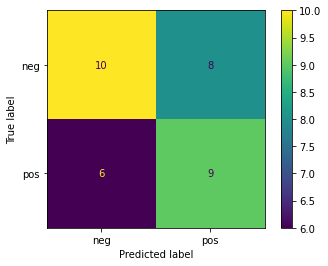

In [243]:
wta_tot=np.nansum(wta,axis=1) > 0
cc=skm.confusion_matrix(true_pos[use],wta_tot[use])
skm.ConfusionMatrixDisplay.from_predictions(true_pos[use],wta_tot[use],
                                            display_labels=learn.dls.vocab)